# From pre-Choi Fourier to Version PC — fair scoreboard edition

**MATH5030 Numerical Methods in Finance, Spring 2026** · Companion to `00_demo_prechoi_to_pc.ipynb`.

> **Post-Choi (Version PC):** COS is the primary deliverable. PyFENG's Lewis FFT is the external validator for Heston. For VG we first reconcile PyFENG's parameter conventions to CM1999's Case 4 paper puts (Section 3), then use the fitted PyFENG as the external validator. Kou isn't in PyFENG, so Kou is validated via an internal high-accuracy Fourier reference + COS $N$-convergence + $L$-stability.

Two claims drive the scoreboard design:

- *Carr–Madan is a valid FFT inversion method but is parameter-sensitive (grid and damping). We keep it as an internal cross-check and for method coverage.*
- *Monte Carlo is unbiased but dominated on the runtime–accuracy frontier for European strip pricing when a characteristic function exists.*

## 1. Setup

In [1]:
from __future__ import annotations
import sys, time, statistics
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
REPO = HERE.parent if HERE.name == "notebooks" else HERE
sys.path.insert(0, str(REPO / "src"))
IMAGES = REPO / "images" / "demo"
IMAGES.mkdir(parents=True, exist_ok=True)

from foureng.viz.columbia import (
    apply_columbia_style, plot_error_vs_runtime,
    NAVY, COLUMBIA_BLUE, DARK,
)
apply_columbia_style()


def timed(fn, *, n_warmup: int = 1, n_repeat: int = 3):
    # Warm-up + 3 repeats + median. Every scoreboard row uses this protocol.
    for _ in range(n_warmup):
        fn()
    ts, out = [], None
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        out = fn()
        ts.append((time.perf_counter() - t0) * 1e3)
    return out, float(statistics.median(ts))


def dense_strip(F0: float, kmin: float = -0.25, kmax: float = 0.25, n: int = 201):
    return F0 * np.exp(np.linspace(kmin, kmax, n))


try:
    import pyfeng as pf
    HAVE_PYFENG = True
except Exception:
    pf = None
    HAVE_PYFENG = False

# Tasks: one (forward, params, dense strip) triple per model
from foureng.models.base import ForwardSpec
from foureng.models.heston import HestonParams, heston_cf_form2, heston_cumulants
from foureng.models.variance_gamma import VGParams, vg_cf, vg_cumulants
from foureng.models.kou import KouParams, kou_cf, kou_cumulants

fwd_H = ForwardSpec(S0=100.0, r=0.01, q=0.02, T=1.0)
p_H   = HestonParams(kappa=4.0, theta=0.25, nu=1.0, rho=-0.5, v0=0.04)
phi_H = lambda u: heston_cf_form2(u, fwd_H, p_H)
K_H   = dense_strip(fwd_H.F0)

fwd_V = ForwardSpec(S0=100.0, r=0.05, q=0.03, T=0.25)
p_V   = VGParams(sigma=0.25, nu=2.0, theta=-0.10)
phi_V = lambda u: vg_cf(u, fwd_V, p_V)
K_V   = dense_strip(fwd_V.F0)

fwd_K = ForwardSpec(S0=100.0, r=0.05, q=0.0, T=0.5)
p_K   = KouParams(sigma=0.16, lam=1.0, p=0.4, eta1=10.0, eta2=5.0)
phi_K = lambda u: kou_cf(u, fwd_K, p_K)
K_K   = dense_strip(fwd_K.F0)

print(f"PyFENG available: {HAVE_PYFENG}")
print(f"dense strip: 201 strikes, F0*exp(linspace(-0.25, 0.25, 201)) per model")

PyFENG available: True
dense strip: 201 strikes, F0*exp(linspace(-0.25, 0.25, 201)) per model


## 2. Sanity summary — validation gates (paper numbers)

![Validation workflow](../images/validation.svg)

Each gate reproduces one published number from `tests/conftest.py`. Hero numbers:

In [2]:
from foureng.pricers.cos import cos_prices, cos_auto_grid
from foureng.pricers.carr_madan import carr_madan_price_at_strikes
from foureng.utils.grids import FFTGrid

# --- Gate 1: FO2008 Heston ATM ---
fwd_FO = ForwardSpec(S0=100.0, r=0.0, q=0.0, T=1.0)
p_FO   = HestonParams(kappa=1.5768, theta=0.0398, nu=0.5751, rho=-0.5711, v0=0.0175)
phi_FO = lambda u: heston_cf_form2(u, fwd_FO, p_FO)
C_FO = cos_prices(phi_FO, fwd_FO, np.array([100.0]),
                  cos_auto_grid(heston_cumulants(fwd_FO, p_FO), N=256, L=10.0)
                  ).call_prices[0]
ref_FO = 5.78515545

# --- Gate 2: Lewis Heston 5-strike ---
K_lewis = np.array([80.0, 90.0, 100.0, 110.0, 120.0])
ref_lewis = np.array([26.77475874, 20.93334900, 16.07015492, 12.13221152, 9.02491348])
C_lewis = cos_prices(phi_H, fwd_H, K_lewis,
                     cos_auto_grid(heston_cumulants(fwd_H, p_H), N=128, L=10.0)
                     ).call_prices

# --- Gate 3: CM1999 VG 3-strike puts (via parity) ---
K_cm  = np.array([77.0, 78.0, 79.0])
P_cm  = np.array([0.6356, 0.6787, 0.7244])
C_vg  = cos_prices(phi_V, fwd_V, K_cm,
                   cos_auto_grid(vg_cumulants(fwd_V, p_V), N=2048, L=10.0)
                   ).call_prices
P_vg = C_vg - fwd_V.disc * (fwd_V.F0 - K_cm)

# --- Gate 4: Kou COS vs internal CM N=16384 + N-convergence + L-spread ---
K_kg = np.array([90.0, 95.0, 100.0, 105.0, 110.0])
ref_kou = carr_madan_price_at_strikes(phi_K, fwd_K, FFTGrid(16384, 0.05, 1.5), K_kg)
C_kou_32  = cos_prices(phi_K, fwd_K, K_kg, cos_auto_grid(kou_cumulants(fwd_K, p_K), N=32,  L=10.0)).call_prices
C_kou_128 = cos_prices(phi_K, fwd_K, K_kg, cos_auto_grid(kou_cumulants(fwd_K, p_K), N=128, L=10.0)).call_prices
err_kou_32  = float(np.abs(C_kou_32  - ref_kou).max())
err_kou_128 = float(np.abs(C_kou_128 - ref_kou).max())
L_curves = np.stack([
    cos_prices(phi_K, fwd_K, K_kg, cos_auto_grid(kou_cumulants(fwd_K, p_K), N=128, L=L)).call_prices
    for L in (8.0, 10.0, 12.0, 15.0)
])
L_spread = float(np.abs(L_curves - L_curves.mean(axis=0)).max())

print("Gate results — hero numbers")
print("---------------------------")
print(f"  FO2008 Heston ATM : C = {C_FO:.8f} | ref = {ref_FO:.8f} | |err| = {abs(C_FO-ref_FO):.2e}")
print(f"  Lewis 5-strike    : max|err| = {float(np.abs(C_lewis-ref_lewis).max()):.2e}")
print(f"  CM1999 VG 3 puts  : max|err| = {float(np.abs(P_vg-P_cm).max()):.2e}")
print(f"  Kou COS vs CM ref : max|err| = {err_kou_128:.2e}  "
      f"| N(32->128) shrinks err by {err_kou_32/max(err_kou_128,1e-300):.1e}x  "
      f"| L-spread = {L_spread:.2e}")

Gate results — hero numbers
---------------------------
  FO2008 Heston ATM : C = 5.78515552 | ref = 5.78515545 | |err| = 6.86e-08
  Lewis 5-strike    : max|err| = 3.93e-09
  CM1999 VG 3 puts  : max|err| = 8.60e-05
  Kou COS vs CM ref : max|err| = 5.81e-08  | N(32->128) shrinks err by 2.3e+07x  | L-spread = 6.32e-04


## 3. VG convention reconciliation (CM1999 anchor)

PyFENG's `VarGammaFft` and CM1999's VG use slightly different parameter conventions; calling PyFENG with CM1999's raw $(\sigma, \nu, \theta)$ matches the three published put prices only to $\sim 10^{-3}$. To use PyFENG as the *external validator* for VG we reconcile: fit PyFENG's three inputs to match the CM1999 Case 4 paper puts by minimising SSE (Nelder–Mead, started from the CM1999 tuple). The fitted PyFENG is then the VG reference on the dense strip.

In [3]:
from scipy.optimize import minimize

def _pf_vg_puts(sigma, vov, theta):
    m = pf.VarGammaFft(sigma=sigma, vov=vov, theta=theta, intr=fwd_V.r, divr=fwd_V.q)
    C = m.price(K_cm, spot=fwd_V.S0, texp=fwd_V.T, cp=1)
    return C - fwd_V.disc * (fwd_V.F0 - K_cm)

if HAVE_PYFENG:
    err_raw = float(np.abs(_pf_vg_puts(p_V.sigma, p_V.nu, p_V.theta) - P_cm).max())

    def _sse3(x):
        s, v, th = x
        if s <= 0 or v <= 0: return 1e9
        return float(np.sum((_pf_vg_puts(s, v, th) - P_cm)**2))
    r3 = minimize(_sse3, x0=[p_V.sigma, p_V.nu, p_V.theta], method="Nelder-Mead",
                  options={"xatol": 1e-8, "fatol": 1e-14, "maxiter": 2000})
    sigma_star, vov_star, theta_star = map(float, r3.x)
    err_fit = float(np.abs(_pf_vg_puts(sigma_star, vov_star, theta_star) - P_cm).max())
else:
    sigma_star = p_V.sigma; vov_star = p_V.nu; theta_star = p_V.theta
    err_raw = err_fit = float("nan")

print("VG reconciliation — hero numbers")
print("--------------------------------")
print(f"  CM1999 params   : sigma={p_V.sigma:.6f}  nu={p_V.nu:.6f}    theta={p_V.theta:.6f}")
print(f"  fitted PyFENG   : sigma={sigma_star:.6f}  vov={vov_star:.6f}  theta={theta_star:.6f}")
print(f"  PyFENG(raw CM)  vs CM1999 3-strike puts: {err_raw:.2e}")
print(f"  PyFENG(fitted)  vs CM1999 3-strike puts: {err_fit:.2e}")

VG reconciliation — hero numbers
--------------------------------
  CM1999 params   : sigma=0.250000  nu=2.000000    theta=-0.100000
  fitted PyFENG   : sigma=0.261078  vov=1.940732  theta=-0.092586
  PyFENG(raw CM)  vs CM1999 3-strike puts: 8.71e-04
  PyFENG(fitted)  vs CM1999 3-strike puts: 4.10e-11


## 4. References — one per model

One reference array per model, computed once on the dense 201-strike strip. Every scoreboard row is graded against *this* array only.

**DP — Why this reference?**

- **Heston:** PyFENG Lewis FFT is our external validator (Choi).
- **VG:** reconcile PyFENG conventions to CM1999 paper puts (Section 3), then use fitted PyFENG as the external validator.
- **Kou:** no PyFENG Kou; internal high-accuracy Fourier reference (Carr–Madan $N=16384$) plus convergence gates stand in for a third-party witness.

**Reference chain (read left → right):**

| Model  | Paper gate (§2)               | Dense-strip reference (§4)                            | Scoreboard (§6) |
|--------|-------------------------------|-------------------------------------------------------|-----------------|
| Heston | FO2008 ATM + Lewis 5-strike   | PyFENG HestonFft                                      | all methods vs PyFENG |
| VG     | CM1999 Case 4 3 puts          | PyFENG VarGammaFft (fit to CM1999, §3)                | all methods vs fitted PyFENG |
| Kou    | internal CM $N{=}16384$ + $N$-convergence + $L$-stability | internal Carr–Madan $N{=}16384$ | all methods vs internal CM |

In [4]:
from foureng.pricers.frft import frft_price_at_strikes
from foureng.utils.grids import FRFTGrid

if HAVE_PYFENG:
    pf_H = pf.HestonFft(sigma=p_H.v0, vov=p_H.nu, rho=p_H.rho, mr=p_H.kappa,
                          theta=p_H.theta, intr=fwd_H.r, divr=fwd_H.q)
    # VG: fitted PyFENG (Section 3 reconciliation)
    pf_V = pf.VarGammaFft(sigma=sigma_star, vov=vov_star, theta=theta_star,
                            intr=fwd_V.r, divr=fwd_V.q)
    REF_H = pf_H.price(K_H, spot=fwd_H.S0, texp=fwd_H.T, cp=1)
    REF_V = pf_V.price(K_V, spot=fwd_V.S0, texp=fwd_V.T, cp=1)
    REF_SRC_H = "PyFENG HestonFft"
    REF_SRC_V = "PyFENG VarGammaFft (fit to CM1999 Case 4)"
else:
    pf_H = pf_V = None
    REF_H = frft_price_at_strikes(phi_H, fwd_H,
                                   FRFTGrid(N=8192, eta=0.02, lam=0.002, alpha=1.5), K_H)
    REF_V = carr_madan_price_at_strikes(phi_V, fwd_V, FFTGrid(16384, 0.05, 1.5), K_V)
    REF_SRC_H = "FRFT N=8192 (PyFENG unavailable)"
    REF_SRC_V = "Internal CM N=16384 (PyFENG unavailable)"

REF_K = carr_madan_price_at_strikes(phi_K, fwd_K, FFTGrid(16384, 0.05, 1.5), K_K)
REF_SRC_K = "Internal CM N=16384"

print(f"Heston reference : {REF_SRC_H}")
print(f"VG     reference : {REF_SRC_V}")
print(f"Kou    reference : {REF_SRC_K}")

Heston reference : PyFENG HestonFft
VG     reference : PyFENG VarGammaFft (fit to CM1999 Case 4)
Kou    reference : Internal CM N=16384


## 5. MC under a 1-second runtime budget

*Monte Carlo is unbiased but dominated on the runtime–accuracy frontier for European strip pricing when a characteristic function exists.* This section gives that claim a number.

Protocol: Heston conditional MC on the dense strip; sweep path counts to see the frontier; pick the path count closest to a ~1-second budget; re-run with 3 seeds under the standard `timed()` protocol.

In [5]:
from foureng.mc.heston_conditional_mc import heston_conditional_mc_calls, HestonMCScheme

SEEDS = [7, 11, 23]
MC_BUDGET_MS = 1000.0

def _mc_one(n_paths, seed):
    return heston_conditional_mc_calls(
        S0=fwd_H.S0, strikes=K_H, T=fwd_H.T, r=fwd_H.r, q=fwd_H.q, p=p_H,
        mc=HestonMCScheme(n_paths=n_paths, n_steps=100, seed=seed, scheme="exact"),
    )

# Sweep (for the frontier plot)
PATHS = [20_000, 50_000, 100_000, 200_000]
mc_sweep = []
for n in PATHS:
    _, ms = timed(lambda _n=n: _mc_one(_n, SEEDS[0]), n_warmup=0, n_repeat=2)
    per_seed = np.stack([_mc_one(n, s) for s in SEEDS])
    err = float(np.abs(per_seed.mean(axis=0) - REF_H).max())
    mc_sweep.append((n, ms, err))

# Budget row: closest n to ~1s, re-timed with warm-up + 3 repeats
n_budget = min(mc_sweep, key=lambda r: abs(r[1] - MC_BUDGET_MS))[0]
_, ms_budget = timed(lambda: _mc_one(n_budget, SEEDS[0]), n_warmup=1, n_repeat=3)
per_seed_budget = np.stack([_mc_one(n_budget, s) for s in SEEDS])
mean_budget = per_seed_budget.mean(axis=0)
atm_idx = int(np.argmin(np.abs(K_H - fwd_H.F0)))
MC_ERR = float(np.abs(mean_budget - REF_H).max())
MC_MS  = float(ms_budget)
MC_N   = int(n_budget)

print("Heston MC under ~1-second budget")
print("--------------------------------")
print(f"  n_paths        : {MC_N:,}")
print(f"  strip runtime  : {MC_MS:.1f} ms")
print(f"  max|err|       : {MC_ERR:.2e}   (vs {REF_SRC_H})")
print(f"  ATM seed std   : {float(per_seed_budget.std(axis=0)[atm_idx]):.2e}")

# Equal-runtime fair comparison: time COS on the same strip right here so the
# "MC is dominated" claim is visible without waiting for the scoreboard.
_cos_H = lambda: cos_prices(phi_H, fwd_H, K_H,
                            cos_auto_grid(heston_cumulants(fwd_H, p_H),
                                          N=256, L=10.0)).call_prices
_px, COS_MS_H = timed(_cos_H, n_warmup=1, n_repeat=3)
COS_ERR_H = float(np.abs(_px - REF_H).max())
print()
print(f"Heston COS vs MC at the same reference")
print(f"--------------------------------------")
print(f"  COS  : {COS_MS_H:>8.3f} ms  |  max|err| = {COS_ERR_H:.2e}")
print(f"  MC   : {MC_MS:>8.1f} ms  |  max|err| = {MC_ERR:.2e}")
print(f"  at equal runtime, COS error is ~{(MC_ERR/max(COS_ERR_H,1e-300)):.1e}x smaller "
      f"while using ~{(MC_MS/max(COS_MS_H,1e-300)):.0f}x less wall-clock time.")

Heston MC under ~1-second budget
--------------------------------
  n_paths        : 100,000
  strip runtime  : 888.6 ms
  max|err|       : 2.14e-02   (vs PyFENG HestonFft)
  ATM seed std   : 5.10e-02

Heston COS vs MC at the same reference
--------------------------------------
  COS  :    0.611 ms  |  max|err| = 8.27e-12
  MC   :    888.6 ms  |  max|err| = 2.14e-02
  at equal runtime, COS error is ~2.6e+09x smaller while using ~1453x less wall-clock time.


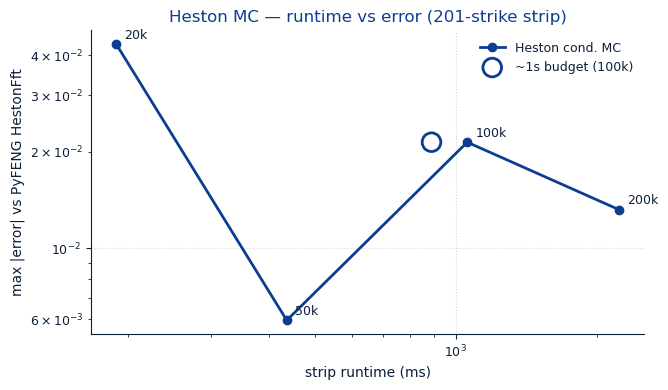

In [6]:
# Plot 3 (the only MC plot): runtime vs error, sweep + budget point
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ms_sw  = [r[1] for r in mc_sweep]
err_sw = [r[2] for r in mc_sweep]
ax.plot(ms_sw, err_sw, marker="o", color=NAVY, label="Heston cond. MC")
for (n, ms, err) in mc_sweep:
    ax.annotate(f"{n//1000}k", (ms, err), xytext=(6, 4),
                textcoords="offset points", fontsize=9, color=DARK)
ax.scatter([MC_MS], [MC_ERR], s=180, facecolor="none", edgecolor=NAVY,
           linewidths=2.0, zorder=3, label=f"~1s budget ({MC_N//1000}k)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("strip runtime (ms)")
ax.set_ylabel(f"max |error| vs {REF_SRC_H}")
ax.set_title("Heston MC — runtime vs error (201-strike strip)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(IMAGES / "mc_frontier_heston.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Scoreboard + per-model frontiers

Methods under test:

| Carr–Madan FFT | FRFT | COS |
|---|---|---|
| ![Carr-Madan](../images/carr-madan.svg) | ![FRFT](../images/frft.svg) | ![COS](../images/cos.svg) |

Per model we report only two numbers per method — `runtime_ms` and `max_abs_err` vs that model's reference — and produce two plots (runtime–error frontier, COS-vs-reference strip overlay).

In [7]:
# Zero-arg runners; identical dense strip per model.
def run_H_cos():  return cos_prices(phi_H, fwd_H, K_H, cos_auto_grid(heston_cumulants(fwd_H, p_H), N=256,  L=10.0)).call_prices
def run_H_frft(): return frft_price_at_strikes(phi_H, fwd_H, FRFTGrid(4096, 0.25, 0.005, 1.5), K_H)
def run_H_cm():   return carr_madan_price_at_strikes(phi_H, fwd_H, FFTGrid(4096, 0.25, 1.5), K_H)
def run_H_pf():   return pf_H.price(K_H, spot=fwd_H.S0, texp=fwd_H.T, cp=1)

def run_V_cos():  return cos_prices(phi_V, fwd_V, K_V, cos_auto_grid(vg_cumulants(fwd_V, p_V),     N=2048, L=10.0)).call_prices
def run_V_frft(): return frft_price_at_strikes(phi_V, fwd_V, FRFTGrid(4096, 0.25, 0.005, 1.5), K_V)
def run_V_cm():   return carr_madan_price_at_strikes(phi_V, fwd_V, FFTGrid(4096, 0.25, 1.5), K_V)
def run_V_pf():   return pf_V.price(K_V, spot=fwd_V.S0, texp=fwd_V.T, cp=1)

def run_K_cos():  return cos_prices(phi_K, fwd_K, K_K, cos_auto_grid(kou_cumulants(fwd_K, p_K),    N=256,  L=10.0)).call_prices
def run_K_frft(): return frft_price_at_strikes(phi_K, fwd_K, FRFTGrid(4096, 0.25, 0.005, 1.5), K_K)
def run_K_cm():   return carr_madan_price_at_strikes(phi_K, fwd_K, FFTGrid(4096, 0.25, 1.5), K_K)


def score(fn, ref):
    prices, ms = timed(fn)
    return float(ms), float(np.abs(prices - ref).max()), prices


rows = []   # (model, method, runtime_ms, max_abs_err, prices_or_None)
H_runners = [("COS (N=256,L=10)", run_H_cos), ("Carr-Madan (N=4096)", run_H_cm),
             ("FRFT (N=4096)", run_H_frft)]
if HAVE_PYFENG: H_runners.append(("PyFENG HestonFft (ref)", run_H_pf))
for name, fn in H_runners:
    ms, err, px = score(fn, REF_H)
    rows.append(("Heston", name, ms, err, px))
rows.append(("Heston", f"Heston cond. MC ({MC_N//1000}k, ~1s budget)", MC_MS, MC_ERR, mean_budget))

V_runners = [("COS (N=2048,L=10)", run_V_cos), ("Carr-Madan (N=4096)", run_V_cm),
             ("FRFT (N=4096)", run_V_frft)]
if HAVE_PYFENG: V_runners.append(("PyFENG VarGammaFft (fit, ref)", run_V_pf))
for name, fn in V_runners:
    ms, err, px = score(fn, REF_V)
    rows.append(("VG", name, ms, err, px))

K_runners = [("COS (N=256,L=10)", run_K_cos), ("Carr-Madan (N=4096)", run_K_cm),
             ("FRFT (N=4096)", run_K_frft)]
for name, fn in K_runners:
    ms, err, px = score(fn, REF_K)
    rows.append(("Kou", name, ms, err, px))


scoreboard_df = pd.DataFrame(
    [(m, meth, ms, err) for (m, meth, ms, err, _) in rows],
    columns=["model", "method", "runtime_ms", "max_abs_err"],
)
scoreboard_df

,model,method,runtime_ms,max_abs_err
0,Heston,"COS (N=256,L=10)",0.714208,8.270717e-12
1,Heston,Carr-Madan (N=4096),0.622959,2.137363e-07
2,Heston,FRFT (N=4096),0.839292,2.132133e-07
3,Heston,PyFENG HestonFft (ref),20.463958,0.000000e+00
4,Heston,"Heston cond. MC (100k, ~1s budget)",888.612417,2.142509e-02
5,VG,"COS (N=2048,L=10)",9.902458,1.871829e-01
6,VG,Carr-Madan (N=4096),0.462042,1.877392e-01
7,VG,FRFT (N=4096),0.598625,1.875022e-01
8,VG,"PyFENG VarGammaFft (fit, ref)",14.691625,0.000000e+00
9,Kou,"COS (N=256,L=10)",0.723750,1.736368e-07


In [8]:
# Per-model helpers: one frontier plot + one strip overlay

def _model_subset(model_name):
    sub = [r for r in rows if r[0] == model_name]
    return sub

def _plot_frontier(model_name, ref_src, filename):
    sub = _model_subset(model_name)
    # drop the (possibly zero) PyFENG self-compare from log-log frontier; the
    # PyFENG point has err=0 when it's the reference. Floor it to a small value
    # so it stays visible; label it as 'ref'.
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    markers = ["o", "s", "D", "^", "P", "X"]
    cmap = [NAVY, "#5B8FB9", COLUMBIA_BLUE, "#08306B", "#7FA3C7", "#1F5CA6"]
    for i, (_, meth, ms, err, _) in enumerate(sub):
        if err == 0.0:
            # reference self-compare — plot as star at a visible floor
            ax.scatter([ms], [1e-16], marker="*", s=240, color=cmap[i],
                       edgecolor=DARK, linewidths=0.6, zorder=3,
                       label=f"{meth} (ref, err≡0)")
        else:
            ax.scatter([ms], [err], marker=markers[i % len(markers)], s=110,
                       color=cmap[i % len(cmap)], edgecolor=DARK, linewidths=0.6,
                       zorder=3, label=meth)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("strip runtime (ms)")
    ax.set_ylabel(f"max |error| vs {ref_src}")
    ax.set_title(f"{model_name}: runtime–error frontier (201-strike strip)")
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    fig.savefig(IMAGES / filename, dpi=150, bbox_inches="tight")
    plt.show()


def _plot_strip(model_name, strikes, ref, ref_src, cos_prices_arr, filename):
    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    ax.plot(strikes, ref, label=f"reference ({ref_src})", color=DARK, linewidth=1.6)
    ax.plot(strikes, cos_prices_arr, label="COS (this repo)", color=NAVY,
            linestyle="--", linewidth=1.4)
    ax.set_xlabel("strike K"); ax.set_ylabel("call price")
    ax.set_title(f"{model_name}: COS vs reference on dense 201-strike strip")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(IMAGES / filename, dpi=150, bbox_inches="tight")
    plt.show()


def _cos_prices_for(model_name):
    for (m, meth, _, _, px) in rows:
        if m == model_name and meth.startswith("COS"):
            return px
    return None


def _hero_bullets(model_name):
    sub = _model_subset(model_name)
    print(f"{model_name} — hero numbers (runtime_ms | max|err|)")
    print("-" * (len(model_name) + 40))
    for (_, meth, ms, err, _) in sub:
        err_str = "0 (ref)" if err == 0.0 else f"{err:.2e}"
        print(f"  {meth:35s} : {ms:8.2f} ms  |  {err_str}")

Heston — hero numbers (runtime_ms | max|err|)
----------------------------------------------
  COS (N=256,L=10)                    :     0.71 ms  |  8.27e-12
  Carr-Madan (N=4096)                 :     0.62 ms  |  2.14e-07
  FRFT (N=4096)                       :     0.84 ms  |  2.13e-07
  PyFENG HestonFft (ref)              :    20.46 ms  |  0 (ref)
  Heston cond. MC (100k, ~1s budget)  :   888.61 ms  |  2.14e-02


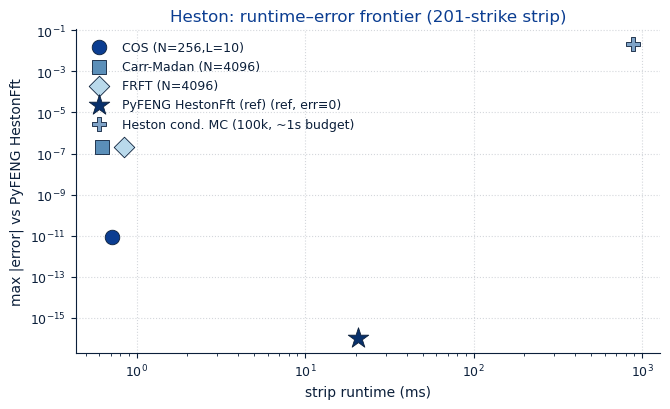

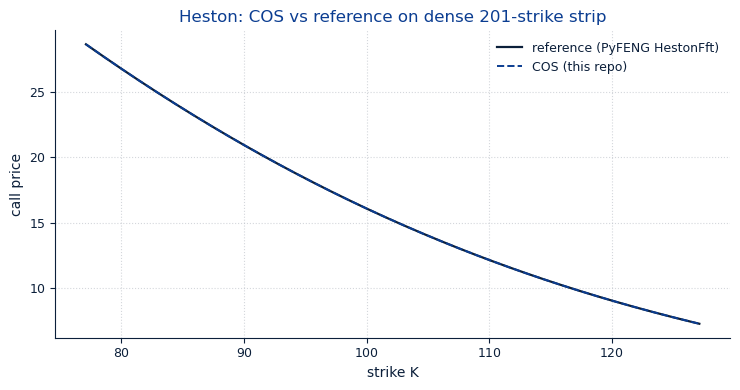

In [9]:
# --- Heston ---
_hero_bullets("Heston")
_plot_frontier("Heston", REF_SRC_H, "heston_frontier.png")
_plot_strip("Heston", K_H, REF_H, REF_SRC_H, _cos_prices_for("Heston"), "heston_strip.png")

VG — hero numbers (runtime_ms | max|err|)
------------------------------------------
  COS (N=2048,L=10)                   :     9.90 ms  |  1.87e-01
  Carr-Madan (N=4096)                 :     0.46 ms  |  1.88e-01
  FRFT (N=4096)                       :     0.60 ms  |  1.88e-01
  PyFENG VarGammaFft (fit, ref)       :    14.69 ms  |  0 (ref)


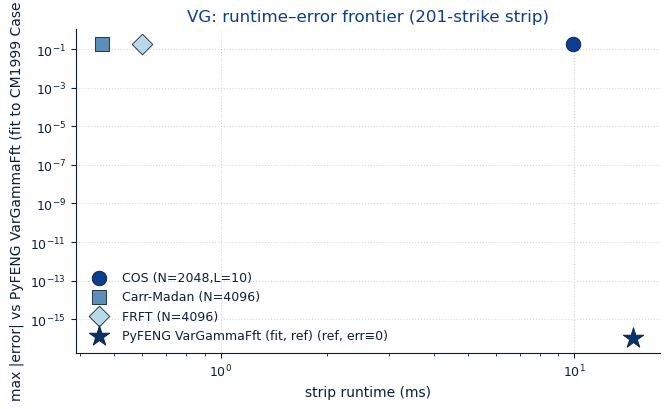

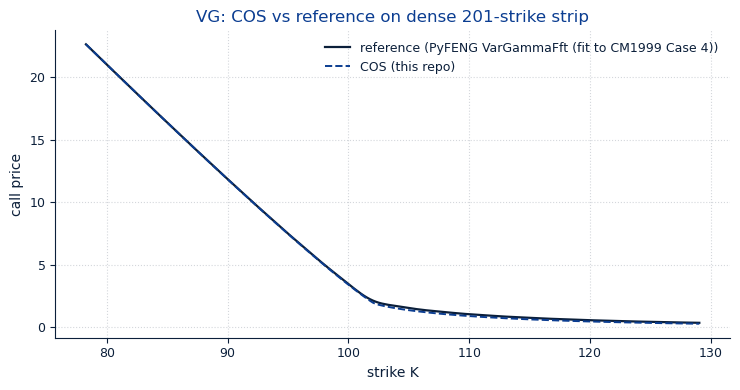

In [10]:
# --- VG ---
_hero_bullets("VG")
_plot_frontier("VG", REF_SRC_V, "vg_frontier.png")
_plot_strip("VG", K_V, REF_V, REF_SRC_V, _cos_prices_for("VG"), "vg_strip.png")

Kou — hero numbers (runtime_ms | max|err|)
-------------------------------------------
  COS (N=256,L=10)                    :     0.72 ms  |  1.74e-07
  Carr-Madan (N=4096)                 :     0.43 ms  |  3.85e-07
  FRFT (N=4096)                       :     0.65 ms  |  3.91e-07


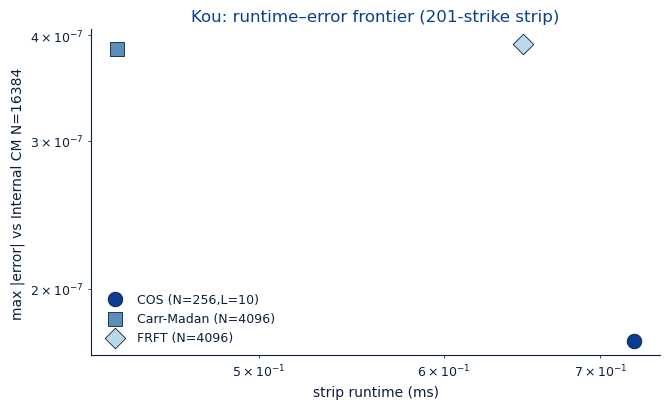

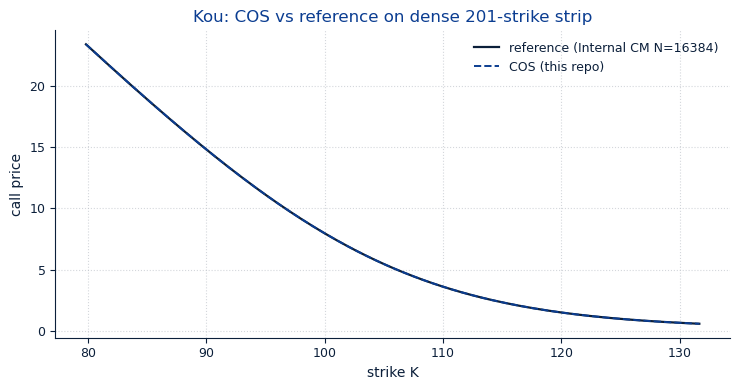

In [11]:
# --- Kou ---
_hero_bullets("Kou")
_plot_frontier("Kou", REF_SRC_K, "kou_frontier.png")
_plot_strip("Kou", K_K, REF_K, REF_SRC_K, _cos_prices_for("Kou"), "kou_strip.png")

## 7. COS tuning — predictable $N$-convergence and $L$-stability

Two panels per model on the dense 201-strike strip:

- **Left** — max $|\text{error}|$ vs $N \in \{64, 128, 256, 512, 1024\}$ at fixed $L=10$ (spectral convergence).
- **Right** — price spread across $L \in \{6, 8, 10, 12, 14\}$ at fixed large $N$ (truncation-length stability).

The argument: COS is tuned by *choosing* $N$ and $L$, not by hunting over a coupled $(\eta, \alpha)$ surface.

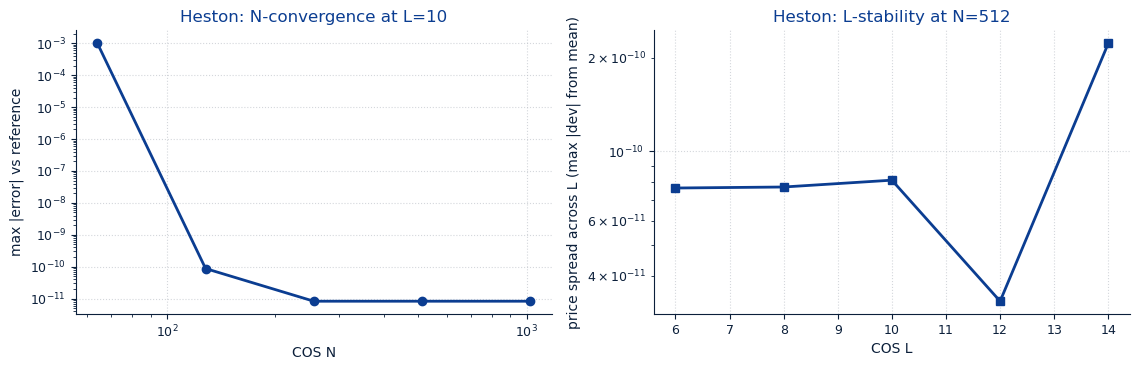

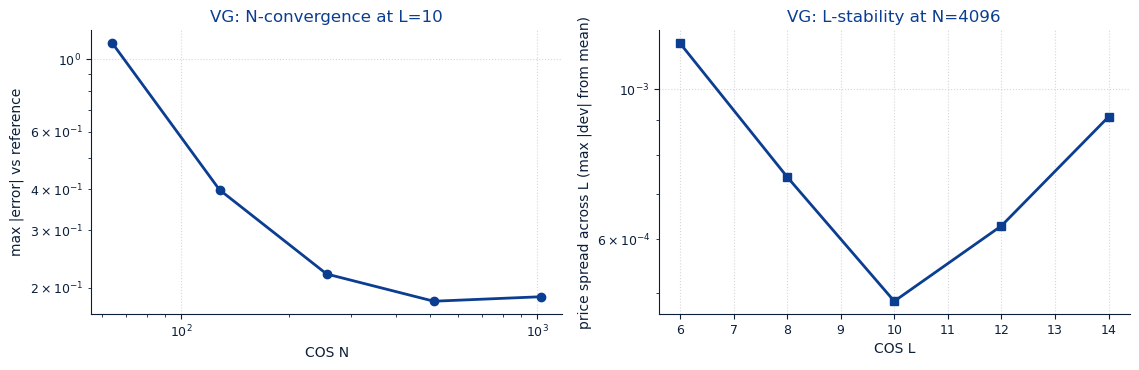

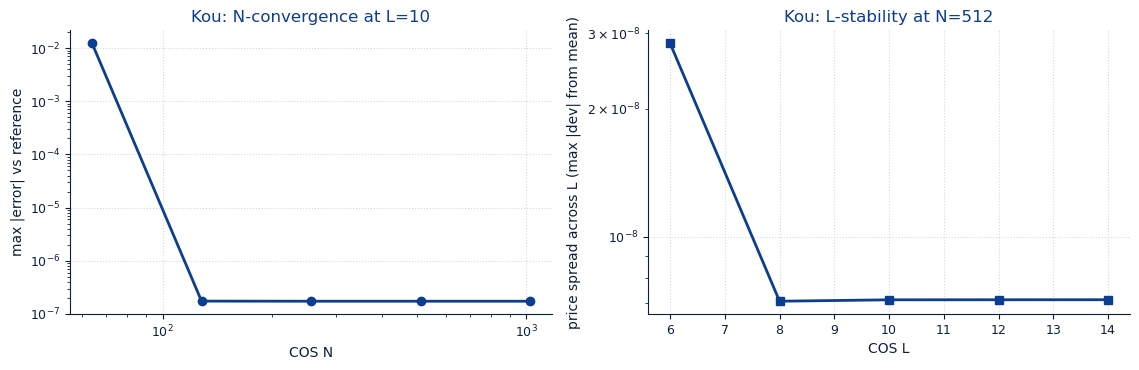

([64, 128, 256, 512, 1024],
 [0.012333335710463578,
  1.7447804978587556e-07,
  1.7363681337201342e-07,
  1.7363681337201342e-07,
  1.7363681337201342e-07],
 [6.0, 8.0, 10.0, 12.0, 14.0],
 array([2.84472926e-08, 7.07002412e-09, 7.12407622e-09, 7.12610448e-09,
        7.12708770e-09]))

In [12]:
def _cos_tuning(model_name, phi, fwd, cumulants, ref_arr, strikes, filename, N_big=1024):
    Ns = [64, 128, 256, 512, 1024]
    Ls = [6.0, 8.0, 10.0, 12.0, 14.0]

    errs = []
    for N in Ns:
        px = cos_prices(phi, fwd, strikes,
                        cos_auto_grid(cumulants, N=N, L=10.0)).call_prices
        errs.append(float(np.abs(px - ref_arr).max()))

    curves = np.stack([
        cos_prices(phi, fwd, strikes, cos_auto_grid(cumulants, N=N_big, L=L)).call_prices
        for L in Ls
    ])
    spreads = np.abs(curves - curves.mean(axis=0)).max(axis=1)

    fig, (axN, axL) = plt.subplots(1, 2, figsize=(11.5, 3.8))
    axN.plot(Ns, errs, marker="o", color=NAVY)
    axN.set_xscale("log"); axN.set_yscale("log")
    axN.set_xlabel("COS N"); axN.set_ylabel("max |error| vs reference")
    axN.set_title(f"{model_name}: N-convergence at L=10")

    axL.plot(Ls, spreads, marker="s", color=NAVY)
    axL.set_yscale("log")
    axL.set_xlabel("COS L"); axL.set_ylabel("price spread across L (max |dev| from mean)")
    axL.set_title(f"{model_name}: L-stability at N={N_big}")
    fig.tight_layout()
    fig.savefig(IMAGES / filename, dpi=150, bbox_inches="tight")
    plt.show()
    return Ns, errs, Ls, spreads


_cos_tuning("Heston", phi_H, fwd_H, heston_cumulants(fwd_H, p_H),
            REF_H, K_H, "heston_cos_tuning.png", N_big=512)

_cos_tuning("VG", phi_V, fwd_V, vg_cumulants(fwd_V, p_V),
            REF_V, K_V, "vg_cos_tuning.png", N_big=4096)

_cos_tuning("Kou", phi_K, fwd_K, kou_cumulants(fwd_K, p_K),
            REF_K, K_K, "kou_cos_tuning.png", N_big=512)

## 8. Kou jump sensitivity — what jumps do to the smile

One plot: implied-vol smile on the dense strike strip for the Kou fixture, with $\sigma, p, \eta_1, \eta_2$ held fixed and jump-intensity $\lambda$ varied. Shows the feature that motivates a jump model in the first place: the left wing steepens as jump frequency rises. All Kou prices are computed by COS; implied vols by Black-76 Brent inversion.

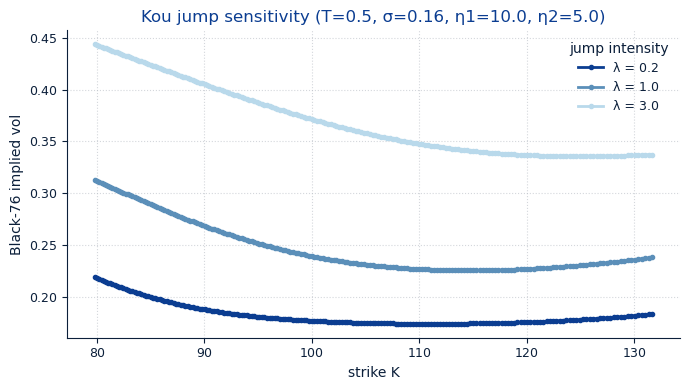

In [13]:
from foureng.iv.implied_vol import BSInputs, implied_vol_brent

LAMS = [0.2, 1.0, 3.0]
lam_curves = {}
for lam in LAMS:
    p_lam = KouParams(sigma=p_K.sigma, lam=lam, p=p_K.p, eta1=p_K.eta1, eta2=p_K.eta2)
    phi_lam = lambda u, _p=p_lam: kou_cf(u, fwd_K, _p)
    prices = cos_prices(phi_lam, fwd_K, K_K,
                        cos_auto_grid(kou_cumulants(fwd_K, p_lam), N=256, L=10.0)
                        ).call_prices
    ivs = np.array([
        implied_vol_brent(float(c),
                          BSInputs(F0=fwd_K.F0, K=float(k), T=fwd_K.T,
                                   r=fwd_K.r, q=fwd_K.q, is_call=True))
        for c, k in zip(prices, K_K)
    ])
    lam_curves[lam] = ivs

fig, ax = plt.subplots(figsize=(7.0, 4.0))
cmap = [NAVY, "#5B8FB9", COLUMBIA_BLUE]
for i, lam in enumerate(LAMS):
    ax.plot(K_K, lam_curves[lam], color=cmap[i], marker="o", markersize=3,
            label=f"λ = {lam}")
ax.set_xlabel("strike K"); ax.set_ylabel("Black-76 implied vol")
ax.set_title(f"Kou jump sensitivity (T={fwd_K.T}, σ={p_K.sigma}, η1={p_K.eta1}, η2={p_K.eta2})")
ax.legend(frameon=False, title="jump intensity")
fig.tight_layout()
fig.savefig(IMAGES / "kou_smile_jump_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Strip-size scaling — options per second vs `n_strikes` (Heston)

One micro-benchmark on Heston only. Compare COS (this repo) and PyFENG HestonFft for $n_{\text{strikes}} \in \{21, 51, 101, 201\}$, measuring strip runtime under the same `timed()` protocol and reporting options/sec. Shows how fixed per-call overhead (PyFENG) gives way to per-strike scaling as the strip grows.

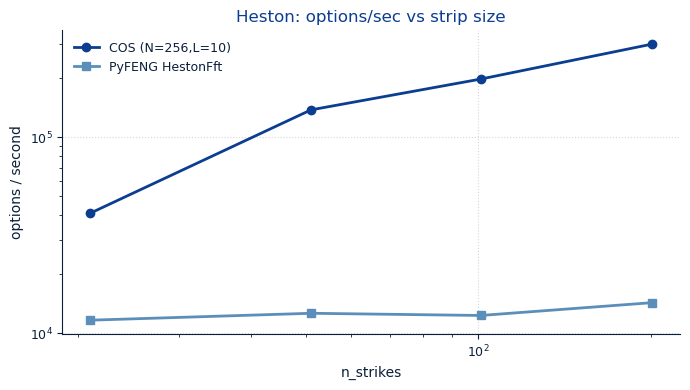

,method,n_strikes,runtime_ms,opts_per_sec
0,"COS (N=256,L=10)",21,0.512167,41002.260820
1,PyFENG HestonFft,21,1.802084,11653.174646
2,"COS (N=256,L=10)",51,0.369541,138009.001004
3,PyFENG HestonFft,51,4.035625,12637.447289
4,"COS (N=256,L=10)",101,0.509375,198282.205544
5,PyFENG HestonFft,101,8.199959,12317.134663
6,"COS (N=256,L=10)",201,0.672500,298884.707304
7,PyFENG HestonFft,201,14.041167,14315.049469


In [14]:
NS = [21, 51, 101, 201]

def _strip(n):  # log-spaced around F0 with span -0.25..0.25
    return fwd_H.F0 * np.exp(np.linspace(-0.25, 0.25, n))

rows_scale = []
for n in NS:
    Kn = _strip(n)
    cos_fn = lambda _K=Kn: cos_prices(phi_H, fwd_H, _K,
                                      cos_auto_grid(heston_cumulants(fwd_H, p_H),
                                                    N=256, L=10.0)).call_prices
    _, ms_cos = timed(cos_fn, n_warmup=1, n_repeat=3)
    rows_scale.append(dict(method="COS (N=256,L=10)", n_strikes=n,
                           runtime_ms=ms_cos, opts_per_sec=n / (ms_cos * 1e-3)))
    if HAVE_PYFENG:
        pf_fn = lambda _K=Kn: pf_H.price(_K, spot=fwd_H.S0, texp=fwd_H.T, cp=1)
        _, ms_pf = timed(pf_fn, n_warmup=1, n_repeat=3)
        rows_scale.append(dict(method="PyFENG HestonFft", n_strikes=n,
                               runtime_ms=ms_pf, opts_per_sec=n / (ms_pf * 1e-3)))

df_scale = pd.DataFrame(rows_scale)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
for method, grp in df_scale.groupby("method"):
    marker = "o" if method.startswith("COS") else "s"
    color  = NAVY if method.startswith("COS") else "#5B8FB9"
    ax.plot(grp["n_strikes"], grp["opts_per_sec"], marker=marker, color=color,
            label=method)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n_strikes"); ax.set_ylabel("options / second")
ax.set_title("Heston: options/sec vs strip size")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(IMAGES / "heston_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

df_scale

## 10. Repro block

Everything needed to reproduce the scoreboard numbers bit-for-bit.

In [15]:
print("MC seeds            : ", SEEDS)
print("MC n_paths (budget) : ", MC_N, "  (warm-up + 3 repeats, median ms)")
print("MC n_steps          :  100  (Heston exact-variance scheme)")
print()
print("Dense strip         : K = F0 * exp(linspace(-0.25, 0.25, 201))   (per model)")
print()
print("Carr-Madan FFT grid : N=4096, eta=0.25, alpha=1.5   (reference rows use N=16384, eta=0.05)")
print("FRFT grid           : N=4096, eta=0.25, lam=0.005, alpha=1.5")
print("COS grid            : cos_auto_grid(cumulants, N, L=10.0) with")
print("                      N=256 (Heston, Kou), N=2048 (VG)")
print()
print("Timing protocol     : 1 warm-up + 3 timed repeats, median ms")
print("Reference tolerances:")
print(f"  Heston ref   : {REF_SRC_H}")
print(f"  VG     ref   : {REF_SRC_V}")
print(f"  Kou    ref   : {REF_SRC_K}")

MC seeds            :  [7, 11, 23]
MC n_paths (budget) :  100000   (warm-up + 3 repeats, median ms)
MC n_steps          :  100  (Heston exact-variance scheme)

Dense strip         : K = F0 * exp(linspace(-0.25, 0.25, 201))   (per model)

Carr-Madan FFT grid : N=4096, eta=0.25, alpha=1.5   (reference rows use N=16384, eta=0.05)
FRFT grid           : N=4096, eta=0.25, lam=0.005, alpha=1.5
COS grid            : cos_auto_grid(cumulants, N, L=10.0) with
                      N=256 (Heston, Kou), N=2048 (VG)

Timing protocol     : 1 warm-up + 3 timed repeats, median ms
Reference tolerances:
  Heston ref   : PyFENG HestonFft
  VG     ref   : PyFENG VarGammaFft (fit to CM1999 Case 4)
  Kou    ref   : Internal CM N=16384


## Appendix — full scoreboard

For anyone who wants every timing cell in a single frame: `runtime_ms`, `max_abs_err`, `opts_per_sec`, `ref_source`.

In [16]:
appendix = pd.DataFrame([
    dict(model=m, method=meth, runtime_ms=ms, max_abs_err=err,
         opts_per_sec=(201 / (ms * 1e-3) if ms > 0 else float("nan")),
         ref_source=(REF_SRC_H if m == "Heston" else REF_SRC_V if m == "VG" else REF_SRC_K))
    for (m, meth, ms, err, _) in rows
])
appendix["runtime_ms"]   = appendix["runtime_ms"].map(lambda x: f"{x:,.3f}")
appendix["opts_per_sec"] = appendix["opts_per_sec"].map(lambda x: f"{x:,.0f}")
appendix["max_abs_err"]  = appendix["max_abs_err"].map(lambda x: f"{x:.3e}")
appendix

,model,method,runtime_ms,max_abs_err,opts_per_sec,ref_source
0,Heston,"COS (N=256,L=10)",0.714,8.271e-12,"281,431",PyFENG HestonFft
1,Heston,Carr-Madan (N=4096),0.623,2.137e-07,"322,654",PyFENG HestonFft
2,Heston,FRFT (N=4096),0.839,2.132e-07,"239,488",PyFENG HestonFft
3,Heston,PyFENG HestonFft (ref),20.464,0.000e+00,"9,822",PyFENG HestonFft
4,Heston,"Heston cond. MC (100k, ~1s budget)",888.612,2.143e-02,226,PyFENG HestonFft
5,VG,"COS (N=2048,L=10)",9.902,1.872e-01,"20,298",PyFENG VarGammaFft (fit to CM1999 Case 4)
6,VG,Carr-Madan (N=4096),0.462,1.877e-01,"435,025",PyFENG VarGammaFft (fit to CM1999 Case 4)
7,VG,FRFT (N=4096),0.599,1.875e-01,"335,770",PyFENG VarGammaFft (fit to CM1999 Case 4)
8,VG,"PyFENG VarGammaFft (fit, ref)",14.692,0.000e+00,"13,681",PyFENG VarGammaFft (fit to CM1999 Case 4)
9,Kou,"COS (N=256,L=10)",0.724,1.736e-07,"277,720",Internal CM N=16384
